# Importance Sampling and SMC

This notebook demonstrates the importance sampling (IS) and Sequential Monte Carlo (SMC)
tools in `psiphy.mcmc.importance_sampling`, applied to the built-in toy models.

## What is importance sampling?

We want to draw samples from a target $p(\theta | x)$ but can only evaluate it up to a constant.
IS draws samples from a tractable proposal $q(\theta)$ and corrects with weights:

$$w_i = \frac{p(\theta_i | x)}{q(\theta_i)}, \qquad \theta_i \sim q$$

The **effective sample size** (ESS) measures how much information the weighted set carries:

$$\text{ESS} = \frac{1}{\sum_i w_i^2} \in [1, N]$$

Low ESS means the proposal is a poor match for the posterior — most weight falls on very few particles.

**SMC** fixes this by annealing from the prior to the posterior through a sequence of tempered targets,
resampling and applying MCMC moves when ESS drops too low.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

from psiphy.mcmc import (
    UniformPrior,
    eff_sample_size,
    importance_sampling,
    sequential_importance_sampling,
    SMC,
)
from psiphy.toy_models import GaussianSignal, NoisyLine

np.random.seed(42)

---
## 1  UniformPrior helper

`UniformPrior` wraps a box prior and provides `sample(n)` and `log_prob(theta)`
— the two methods expected by `importance_sampling` and `SMC`.

In [2]:
prior = UniformPrior({'mean': (-5, 5), 'sigma': (0.1, 5)})
print('ndim  :', prior.ndim)
print('sample:', prior.sample(3))
print('log_prob in support  :', prior.log_prob([0.0, 1.0]))
print('log_prob out of support:', prior.log_prob([10.0, 1.0]))

ndim  : 2
sample: [[-1.25459881  4.7585001 ]
 [ 2.31993942  3.03342657]
 [-3.4398136   0.86437315]]
log_prob in support  : -3.891820298110627
log_prob out of support: -inf


---
## 2  Importance Sampling — GaussianSignal

Target: posterior $p(\mu, \sigma \mid x)$ for a Gaussian signal with $N=40$ observations.

In [3]:
gs = GaussianSignal(N=40)
theta_true = np.array([1.5, 0.8])
x_obs = gs.simulate(theta_true)

print(f'x_obs  mean={x_obs.mean():.3f}  std={x_obs.std():.3f}  (true: {theta_true})')

x_obs  mean=1.250  std=0.734  (true: [1.5 0.8])


In [4]:
# Broad uniform prior — deliberate mismatch to show ESS degradation
prior_broad = UniformPrior([(-5, 5), (0.1, 5)])
log_posterior = lambda t: gs.log_prob(t, x_obs) + prior_broad.log_prob(t)

proposal_broad = prior_broad.sample(5000)
s_broad, w_broad = importance_sampling(log_posterior, proposal_broad)
ess_broad = eff_sample_size(w_broad)
print(f'Broad proposal  — ESS = {ess_broad:.1f} / 5000 ({100*ess_broad/5000:.1f}%)')

Broad proposal  — ESS = 11.4 / 5000 (0.2%)


In [5]:
# Tighter prior centred near the posterior — higher ESS
prior_tight = UniformPrior([(0.0, 3.0), (0.3, 2.0)])
log_posterior_tight = lambda t: gs.log_prob(t, x_obs) + prior_tight.log_prob(t)

proposal_tight = prior_tight.sample(5000)
s_tight, w_tight = importance_sampling(log_posterior_tight, proposal_tight)
ess_tight = eff_sample_size(w_tight)
print(f'Tight proposal  — ESS = {ess_tight:.1f} / 5000 ({100*ess_tight/5000:.1f}%)')

Tight proposal  — ESS = 114.1 / 5000 (2.3%)


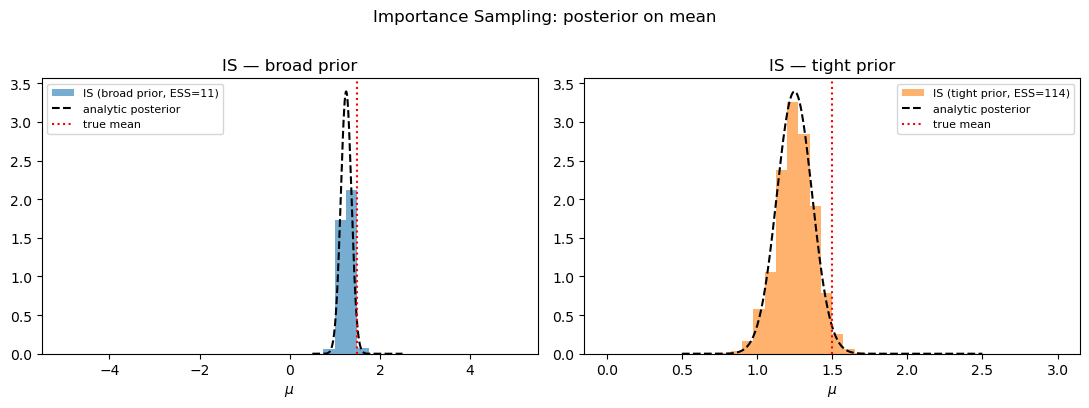

In [6]:
# Analytic posterior on mean for comparison (sigma plugged in as sample std)
post_mean, post_sigma = gs.analytic_posterior(x_obs)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

mu_grid = np.linspace(0.5, 2.5, 300)

for ax, samples, w, label, color in [
    (axes[0], proposal_broad, w_broad, 'broad prior', 'C0'),
    (axes[1], proposal_tight, w_tight, 'tight prior', 'C1'),
]:
    ess = eff_sample_size(w)
    ax.hist(samples[:, 0], weights=w, bins=40, density=True,
            alpha=0.6, color=color, label=f'IS ({label}, ESS={ess:.0f})')
    ax.plot(mu_grid, norm.pdf(mu_grid, post_mean, post_sigma),
            'k--', lw=1.5, label='analytic posterior')
    ax.axvline(theta_true[0], c='red', lw=1.5, ls=':', label='true mean')
    ax.set(xlabel=r'$\mu$', title=f'IS — {label}')
    ax.legend(fontsize=8)

plt.suptitle('Importance Sampling: posterior on mean', y=1.01)
plt.tight_layout()
plt.show()

**Key takeaway:** the broad uniform proposal samples mostly from regions of low likelihood,
yielding very few effective samples. A tighter proposal that overlaps the posterior better
gives a far higher ESS and more accurate estimate.

---
## 3  Effective Sample Size as a diagnostic

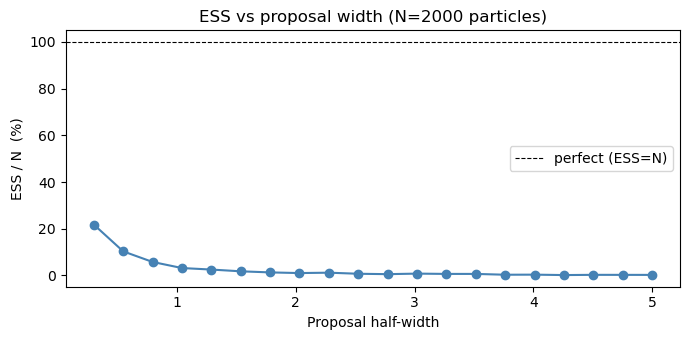

In [7]:
# Show how ESS changes with proposal width
half_widths = np.linspace(0.3, 5.0, 20)
ess_list = []

for hw in half_widths:
    p = UniformPrior([
        (theta_true[0] - hw, theta_true[0] + hw),
        (max(0.1, theta_true[1] - hw), theta_true[1] + hw),
    ])
    prop = p.sample(2000)
    _, w = importance_sampling(lambda t: gs.log_prob(t, x_obs) + p.log_prob(t), prop)
    ess_list.append(eff_sample_size(w) / 2000 * 100)

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(half_widths, ess_list, 'o-', c='steelblue')
ax.set(xlabel='Proposal half-width', ylabel='ESS / N  (%)',
       title='ESS vs proposal width (N=2000 particles)')
ax.axhline(100, ls='--', c='k', lw=0.8, label='perfect (ESS=N)')
ax.legend()
plt.tight_layout()
plt.show()

---
## 4  Importance Sampling — NoisyLine

Two parameters: slope and intercept.

In [8]:
nl = NoisyLine(Nx=40, noise_sigma=0.5)
theta_nl = np.array([-0.8, 5.0])
y_obs = nl.simulate(theta_nl)

prior_nl = UniformPrior([(-3, 3), (0, 10)])
log_post_nl = lambda t: nl.log_prob(t, y_obs) + prior_nl.log_prob(t)

prop_nl = prior_nl.sample(8000)
s_nl, w_nl = importance_sampling(log_post_nl, prop_nl)
ess_nl = eff_sample_size(w_nl)
print(f'NoisyLine IS  ESS={ess_nl:.1f}/8000  '
      f'slope={s_nl[:,0].mean():.3f} (true {theta_nl[0]})  '
      f'intercept={s_nl[:,1].mean():.3f} (true {theta_nl[1]})')

NoisyLine IS  ESS=4.2/8000  slope=-0.832 (true -0.8)  intercept=5.280 (true 5.0)


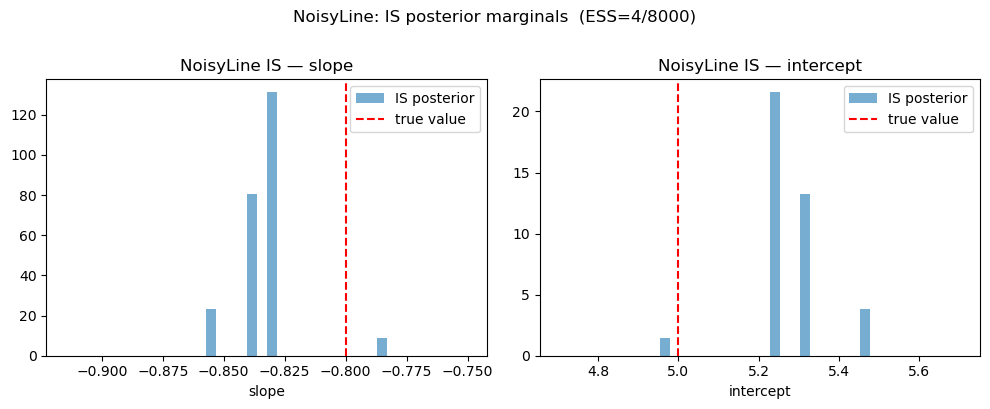

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, idx, name, true_val in [
    (axes[0], 0, 'slope', theta_nl[0]),
    (axes[1], 1, 'intercept', theta_nl[1]),
]:
    ax.hist(s_nl[:, idx], weights=w_nl, bins=40, density=True, alpha=0.6, label='IS posterior')
    ax.axvline(true_val, c='red', lw=1.5, ls='--', label='true value')
    ax.set(xlabel=name, title=f'NoisyLine IS — {name}')
    ax.legend()

plt.suptitle(f'NoisyLine: IS posterior marginals  (ESS={ess_nl:.0f}/8000)', y=1.01)
plt.tight_layout()
plt.show()

---
## 5  SMC — annealing from prior to posterior

SMC overcomes the low-ESS problem by bridging from the prior to the
posterior through tempered targets $p_t \propto \text{prior} \times \mathcal{L}^{\beta_t}$.
When ESS drops below a threshold, particles are resampled and a Gaussian
random-walk MCMC move is applied to maintain diversity.

In [10]:
# GaussianSignal with broad prior — compare IS vs SMC
prior_broad2 = UniformPrior([(-5, 5), (0.1, 5)])

# IS baseline
prop = prior_broad2.sample(1000)
s_is, w_is = importance_sampling(
    lambda t: gs.log_prob(t, x_obs) + prior_broad2.log_prob(t), prop
)
print(f'IS  ESS={eff_sample_size(w_is):.1f}/1000')

# SMC
s_smc, w_smc = SMC(
    lambda t: gs.log_prob(t, x_obs),
    prior_broad2,
    n_particles=1000,
    n_steps=10,
    verbose=True,
)
print(f'SMC ESS={eff_sample_size(w_smc):.1f}/1000')

IS  ESS=1.5/1000


SMC:   0%|          | 0/10 [00:00<?, ?it/s]

SMC ESS=755.7/1000


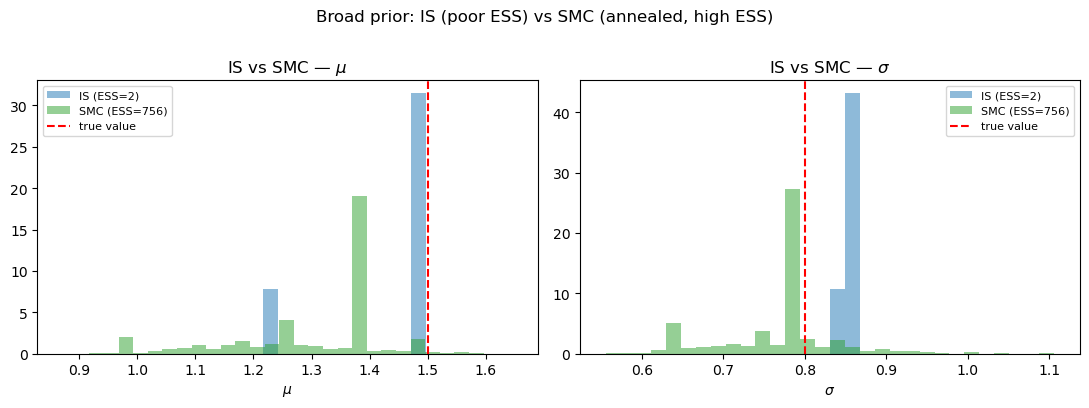

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, name, idx, true_val in [
    (axes[0], r'$\mu$', 0, theta_true[0]),
    (axes[1], r'$\sigma$', 1, theta_true[1]),
]:
    ax.hist(s_is[:, idx], weights=w_is, bins=30, density=True,
            alpha=0.5, label=f'IS (ESS={eff_sample_size(w_is):.0f})', color='C0')
    ax.hist(s_smc[:, idx], weights=w_smc, bins=30, density=True,
            alpha=0.5, label=f'SMC (ESS={eff_sample_size(w_smc):.0f})', color='C2')
    ax.axvline(true_val, c='red', lw=1.5, ls='--', label='true value')
    ax.set(xlabel=name, title=f'IS vs SMC — {name}')
    ax.legend(fontsize=8)

plt.suptitle('Broad prior: IS (poor ESS) vs SMC (annealed, high ESS)', y=1.01)
plt.tight_layout()
plt.show()

---
## 6  2-D posterior scatter: SMC on NoisyLine

In [12]:
prior_nl2 = UniformPrior([(-3, 3), (0, 10)])

smc_nl, w_nl2 = SMC(
    lambda t: nl.log_prob(t, y_obs),
    prior_nl2,
    n_particles=1000,
    n_steps=10,
    verbose=True,
)
print(f'NoisyLine SMC  ESS={eff_sample_size(w_nl2):.1f}/1000')
print(f'slope     = {smc_nl[:,0].mean():.3f} ± {smc_nl[:,0].std():.3f}  (true {theta_nl[0]})')
print(f'intercept = {smc_nl[:,1].mean():.3f} ± {smc_nl[:,1].std():.3f}  (true {theta_nl[1]})')

SMC:   0%|          | 0/10 [00:00<?, ?it/s]

NoisyLine SMC  ESS=818.2/1000
slope     = -0.825 ± 0.028  (true -0.8)
intercept = 5.224 ± 0.175  (true 5.0)


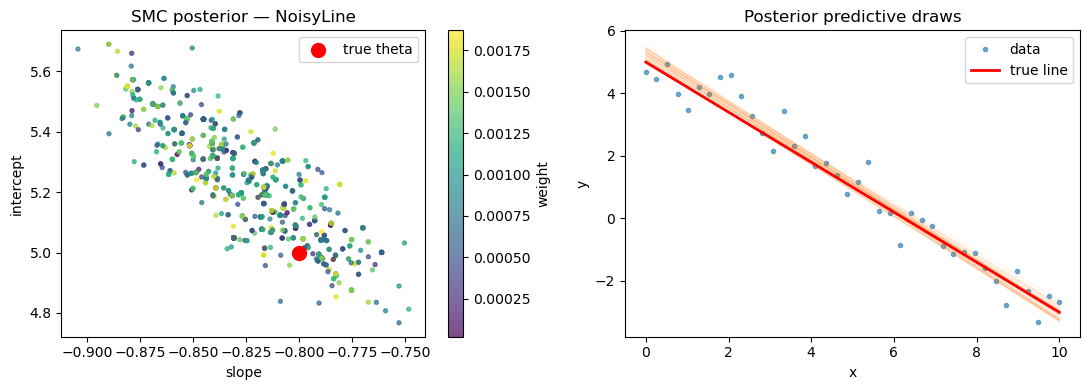

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sc = axes[0].scatter(smc_nl[:, 0], smc_nl[:, 1],
                     c=w_nl2, cmap='viridis', s=8, alpha=0.7)
axes[0].scatter(*theta_nl, c='red', s=100, zorder=5, label='true theta')
plt.colorbar(sc, ax=axes[0], label='weight')
axes[0].set(xlabel='slope', ylabel='intercept',
            title='SMC posterior — NoisyLine')
axes[0].legend()

axes[1].plot(nl.x, y_obs, '.', alpha=0.6, label='data')
for s, i in smc_nl[np.random.choice(len(smc_nl), 80)]:
    axes[1].plot(nl.x, s * nl.x + i, alpha=0.05, c='C1', lw=0.8)
axes[1].plot(nl.x, theta_nl[0] * nl.x + theta_nl[1], 'r-', lw=2, label='true line')
axes[1].set(xlabel='x', ylabel='y', title='Posterior predictive draws')
axes[1].legend()

plt.tight_layout()
plt.show()

---
## Summary

| Method | When to use | ESS behaviour |
|---|---|---|
| `importance_sampling` | Proposal already close to posterior | Degrades quickly if proposal is too broad |
| `sequential_importance_sampling` | Moderate mismatch, iterative refinement | Better than plain IS; no annealing schedule |
| `SMC` | Broad prior, multi-modal, or expensive likelihood | Maintains high ESS via annealing + MCMC move |

All three accept any `log_target_fn` / `log_likelihood_fn` and a `UniformPrior` (or any object with `.sample(n)` and `.log_prob(theta)`).